# Notebook principal — INF6243

Ce notebook exécute le pipeline complet et affiche les résultats clés.

In [1]:
from pathlib import Path
from IPython.display import display, Markdown, Image

import sys
sys.path.insert(0, "Code")
from notebook_workflow import (
    build_models_table,
    build_runs_comparison_table,
    load_report,
    run_all_configs,
)
from result_interpreter import interpret_report

In [2]:
# Strategie multi-runs: configurations definies dans le notebook.
def get_default_runs() -> dict:
    """Retourne les configurations de runs par défaut.

    Paramètres de configuration (appliqués dans chaque run):
        - max_samples (int | None): taille max de l'échantillon stratifié.
            Valeurs recommandées: None (100% du dataset) ou entier > 1000.
        - distilbert_epochs (int): nombre d'epochs pour DistilBERT.
            Range recommandé: 1 à 5 (1 rapide, 2-3 standard, >3 plus coûteux).
        - include_distilbert (bool): inclut ou non DistilBERT dans la comparaison.
            Valeurs: True ou False.
        - test_size (float): proportion du jeu de test.
            Range valide: 0.1 à 0.4 (strictement entre 0 et 1).
        - val_size (float): proportion du jeu de validation.
            Range valide: 0.05 à 0.3 (strictement entre 0 et 1).
        - cv_folds (int): nombre de folds pour la validation croisée.
            Range recommandé: 3 à 10.
        - scoring (str): métrique sklearn utilisée pour GridSearchCV.
            Valeurs typiques: "f1_macro", "accuracy", "precision_macro", "recall_macro".
        - selection_weights (tuple[float, float, float]): poids (validation, test, cv)
            du score de sélection final.
            Range recommandé: chaque poids entre 0 et 1, somme = 1.0.
        - random_state (int): seed de reproductibilité.
            Valeur recommandée: entier positif (ex: 42).

    Retour:
        Dictionnaire des runs prêts à exécuter par `run_all_configs()`.
    """
    # Parametres communs (non mouvants entre les runs)
    TEST_SIZE = 0.2
    VAL_SIZE = 0.1
    SCORING = "f1_macro"
    RANDOM_STATE = 42

    # Parametres partages par sous-groupes de runs
    CV_FOLDS_STANDARD = 5
    CV_FOLDS_FAST = 3
    WEIGHTS_BALANCED = (0.35, 0.40, 0.25)
    WEIGHTS_TEST_PRIORITY = (0.35, 0.45, 0.20)

    return {
        "run_a_data_balance": {
            "why": (
                "Run A = baseline robuste sur plus de donnees. "
                "On utilise 100% des echantillons pour mieux couvrir la classe minoritaire hate_speech."
            ),
            "config": {
                "max_samples": None,
                "distilbert_epochs": 1,
                "include_distilbert": True,
                "test_size": TEST_SIZE,
                "val_size": VAL_SIZE,
                "cv_folds": CV_FOLDS_STANDARD,
                "scoring": SCORING,
                "selection_weights": WEIGHTS_BALANCED,
                "random_state": RANDOM_STATE,
            },
        },
        "run_b_data-low_balance": {
            "why": (
                "Run B = baseline robuste sur peu de donnees. "
                "On utilise 12000 max_samples pour évaluer l'echantillonage."
            ),
            "config": {
                "max_samples": 12000,
                "distilbert_epochs": 1,
                "include_distilbert": True,
                "test_size": TEST_SIZE,
                "val_size": VAL_SIZE,
                "cv_folds": CV_FOLDS_STANDARD,
                "scoring": SCORING,
                "selection_weights": WEIGHTS_BALANCED,
                "random_state": RANDOM_STATE,
            },
        },
        "run_c_classic_focus": {
            "why": (
                "Run B = focus modeles classiques. "
                "On retire DistilBERT pour mesurer la performance pure TF-IDF+ML avec CV complete."
            ),
            "config": {
                "max_samples": None,
                "distilbert_epochs": 1,
                "include_distilbert": False,
                "test_size": TEST_SIZE,
                "val_size": VAL_SIZE,
                "cv_folds": CV_FOLDS_STANDARD,
                "scoring": SCORING,
                "selection_weights": WEIGHTS_TEST_PRIORITY,
                "random_state": RANDOM_STATE,
            },
        },
        "run_d_distilbert_focus": {
            "why": (
                "Run C = focus deep learning. "
                "On augmente les epochs DistilBERT pour voir si le rappel macro progresse, "
                "avec un CV plus court pour garder un temps d'execution raisonnable."
            ),
            "config": {
                "max_samples": None,
                "distilbert_epochs": 2,
                "include_distilbert": True,
                "test_size": TEST_SIZE,
                "val_size": VAL_SIZE,
                "cv_folds": CV_FOLDS_FAST,
                "scoring": SCORING,
                "selection_weights": WEIGHTS_TEST_PRIORITY,
                "random_state": RANDOM_STATE,
            },
        },
        "run_e_distlong3_focus": {
            "why": (
                "Run C = focus deep learning. "
                "On augmente les epochs DistilBERT pour voir si le rappel macro progresse, "
                "avec un CV plus court pour garder un temps d'execution raisonnable."
            ),
            "config": {
                "max_samples": None,
                "distilbert_epochs": 3,
                "include_distilbert": True,
                "test_size": TEST_SIZE,
                "val_size": VAL_SIZE,
                "cv_folds": CV_FOLDS_FAST,
                "scoring": SCORING,
                "selection_weights": WEIGHTS_TEST_PRIORITY,
                "random_state": RANDOM_STATE,
            },
        },
    }


RUNS = get_default_runs()

# Option: surcharge locale d'un run si besoin (exemple)
# RUNS["run_c_distilbert_focus"]["config"]["distilbert_epochs"] = 3

workflow = run_all_configs(RUNS)
run_summary_df = workflow["run_summary_df"]
BEST_RUN = workflow["best_run"]
artifacts = workflow["artifacts"]
FIGURE_NAMES = workflow["figure_names"]

display(run_summary_df)
print(f"Run de reference selectionne pour la suite: {BEST_RUN}")
artifacts

Execution: run_a_data_balance
Pourquoi: Run A = baseline robuste sur plus de donnees. On utilise 100% des echantillons pour mieux couvrir la classe minoritaire hate_speech.
Configuration: {'max_samples': None, 'distilbert_epochs': 1, 'include_distilbert': True, 'test_size': 0.2, 'val_size': 0.1, 'cv_folds': 5, 'scoring': 'f1_macro', 'selection_weights': (0.35, 0.4, 0.25), 'random_state': 42}
Device détecté (pour deep learning): cuda


/home/kilo/Work/Cours - UQO/Sujet Special/sysdereco_devoir2/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/home/kilo/Work/Cours - UQO/Sujet Special/sysdereco_devoir2/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/17347 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

Report run sauvegarde: /home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/reports/metrics_report_run_e_distlong3_focus.json


,run,best_model,best_selection_score,best_test_f1_macro,report_path
4,run_e_distlong3_focus,DistilBERT,0.754151,0.756403,/home/kilo/Work/Cours - UQO/Technique d'Appren...
3,run_d_distilbert_focus,DistilBERT,0.741193,0.754313,/home/kilo/Work/Cours - UQO/Technique d'Appren...
2,run_c_classic_focus,LogisticRegression,0.729664,0.732661,/home/kilo/Work/Cours - UQO/Technique d'Appren...
0,run_a_data_balance,LogisticRegression,0.729521,0.732661,/home/kilo/Work/Cours - UQO/Technique d'Appren...
1,run_b_data-low_balance,RandomForest,0.721170,0.725038,/home/kilo/Work/Cours - UQO/Technique d'Appren...


Run de reference selectionne pour la suite: run_e_distlong3_focus


{'best_model_name': 'DistilBERT',
 'best_model_path': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/reports/best_model_deep_learning_note.json",
 'report_path': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/reports/metrics_report.json",
 'figures_dir': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs/figures",
 'outputs_dir': "/home/kilo/Work/Cours - UQO/Technique d'Apprentissage/Tech-App-Devoir-II/Outputs"}

## Pourquoi separer en plusieurs runs ?

- **Run A (data balance)**: verifier l'impact d'un volume de donnees maximal sur les classes rares.
- **Run B (classic focus)**: isoler les modeles classiques pour une comparaison propre avec CV complete et cout modere.
- **Run C (DistilBERT focus)**: tester une hypothese deep learning differente (plus d'epochs) sans confondre avec les autres facteurs.

Cette separation permet de faire des decisions plus fiables: chaque run teste une idee principale avec des parametres coherents pour cette idee.

In [3]:
report = load_report(Path(artifacts["report_path"]))

print("Meilleur modèle:", report.get("best_model"))
print("Métriques test:", report.get("best_model_test_metrics"))
print("DistilBERT:", report.get("distilbert_note"))
print("Configuration:", report.get("run_config"))
display(Markdown("**Justification:** " + report.get("best_model_selection_explanation", "")))

Meilleur modèle: DistilBERT
Métriques test: {'accuracy': 0.9108331652208997, 'precision_macro': 0.7741784368030727, 'recall_macro': 0.742595858022748, 'f1_macro': 0.7564030647891323}
DistilBERT: DistilBERT inclus dans la comparaison.
Configuration: {'max_samples': None, 'distilbert_epochs': 3, 'include_distilbert': True, 'test_size': 0.2, 'val_size': 0.1, 'cv_folds': 3, 'scoring': 'f1_macro', 'selection_weights': [0.35, 0.45, 0.2], 'random_state': 42}


**Justification:** Le modèle DistilBERT obtient le meilleur score global pondéré (0.7542) en combinant validation, test et CV. Il est retenu pour son compromis entre performance et robustesse.

In [4]:
# Tableau complet: tous les modèles, statut, métriques, hyperparamètres
build_models_table(report)

,model,status,error_or_reason,selection_score,val_f1_macro,test_f1_macro,cv_f1_macro_mean,representation,best_cv_score,best_params
7,DistilBERT,trained,None,0.754151,0.752308,0.756403,0.752308,Transformer embeddings,NaN,"{'model_name': 'distilbert-base-uncased', 'epo..."
5,RandomForest,trained,None,0.732546,0.737587,0.731765,0.725480,TF-IDF sparse vectors,0.726783,"{'clf__max_depth': None, 'clf__max_features': ..."
1,LogisticRegression,trained,None,0.729170,0.725725,0.732661,0.727342,TF-IDF sparse vectors,0.723277,"{'clf__C': 2.0, 'tfidf__min_df': 2, 'tfidf__ng..."
2,LinearSVC,trained,None,0.726513,0.716941,0.733827,0.726809,TF-IDF sparse vectors,0.727679,"{'clf__C': 0.5, 'tfidf__min_df': 2, 'tfidf__ng..."
4,DecisionTree,trained,None,0.696534,0.691962,0.701517,0.693321,TF-IDF sparse vectors,0.686854,"{'clf__ccp_alpha': 0.0, 'clf__max_depth': 40, ..."
6,MLPClassifier,trained,None,0.574706,0.579020,0.573303,0.570314,TF-IDF sparse vectors,0.586033,"{'clf__alpha': 0.0001, 'clf__hidden_layer_size..."
0,NaiveBayes,trained,None,0.519581,0.519099,0.521908,0.515189,TF-IDF sparse vectors,0.512125,"{'clf__alpha': 0.5, 'tfidf__min_df': 5, 'tfidf..."
3,KNN,trained,None,0.357258,0.357372,0.354593,0.363055,TF-IDF sparse vectors,0.347274,"{'clf__n_neighbors': 3, 'clf__weights': 'dista..."


In [5]:
# Interpreteur de resultats (script dedie)
interpreter_summary = interpret_report(report, weak_f1_threshold=0.55)
interpreter_summary

=== INTERPRETATION RAPIDE ===
Meilleur modele: DistilBERT
Score de selection: 0.7542

Statuts des modeles:
trained: 8

Top 3 modeles (score global): ['DistilBERT', 'RandomForest', 'LogisticRegression']

Diagnostic par modele entraine:
- DistilBERT: selection=0.7542 | val_f1=0.7523 | test_f1=0.7564 | cv_mean=0.7523 | generalisation stable | stabilite forte
- RandomForest: selection=0.7325 | val_f1=0.7376 | test_f1=0.7318 | cv_mean=0.7255 | generalisation stable | stabilite forte
- LogisticRegression: selection=0.7292 | val_f1=0.7257 | test_f1=0.7327 | cv_mean=0.7273 | generalisation stable | stabilite forte
- LinearSVC: selection=0.7265 | val_f1=0.7169 | test_f1=0.7338 | cv_mean=0.7268 | generalisation stable | stabilite forte
- DecisionTree: selection=0.6965 | val_f1=0.6920 | test_f1=0.7015 | cv_mean=0.6933 | generalisation stable | stabilite forte
- MLPClassifier: selection=0.5747 | val_f1=0.5790 | test_f1=0.5733 | cv_mean=0.5703 | generalisation stable | stabilite forte
- NaiveBayes:

{'status_counts': {'trained': 8},
 'top_models': ['DistilBERT', 'RandomForest', 'LogisticRegression'],
 'weak_models': [('KNN', 0.35459263631287485),
  ('NaiveBayes', 0.521908210334494)]}

## Pourquoi `best_cv_score` peut être vide pour DistilBERT ?

- Les modèles classiques utilisent `GridSearchCV`, donc un `best_cv_score` est produit.
- DistilBERT est entraîné en fine-tuning direct (pas de GridSearchCV complet pour limiter le coût).
- Le fallback de robustesse est documenté dans `model_selection_method.cv_fallback_for_models`.

In [6]:
# Comparaison inter-runs (si plusieurs runs ont ete executes)
reports_dir = Path(artifacts["report_path"]).parent
comparison_df = build_runs_comparison_table(reports_dir)

if comparison_df.empty:
    print("Aucun report multi-run detecte.")
else:
    display(comparison_df)
    print("Astuce: la comparaison est aussi disponible en figure (runs_comparison_overview.png).")

,run,best_model,best_selection_score,best_test_f1_macro,distilbert_note
6,run_e_distlong3_focus,DistilBERT,0.754151,0.756403,DistilBERT inclus dans la comparaison.
4,run_c_distilbert_focus,DistilBERT,0.741193,0.754313,DistilBERT inclus dans la comparaison.
5,run_d_distilbert_focus,DistilBERT,0.741193,0.754313,DistilBERT inclus dans la comparaison.
1,run_b_classic_focus,LogisticRegression,0.729664,0.732661,DistilBERT ignoré: dépendances deep learning n...
3,run_c_classic_focus,LogisticRegression,0.729664,0.732661,DistilBERT ignoré: dépendances deep learning n...
0,run_a_data_balance,LogisticRegression,0.729521,0.732661,DistilBERT inclus dans la comparaison.
2,run_b_data-low_balance,RandomForest,0.721170,0.725038,DistilBERT inclus dans la comparaison.


Astuce: la comparaison est aussi disponible en figure (runs_comparison_overview.png).


### runs_comparison_overview.png

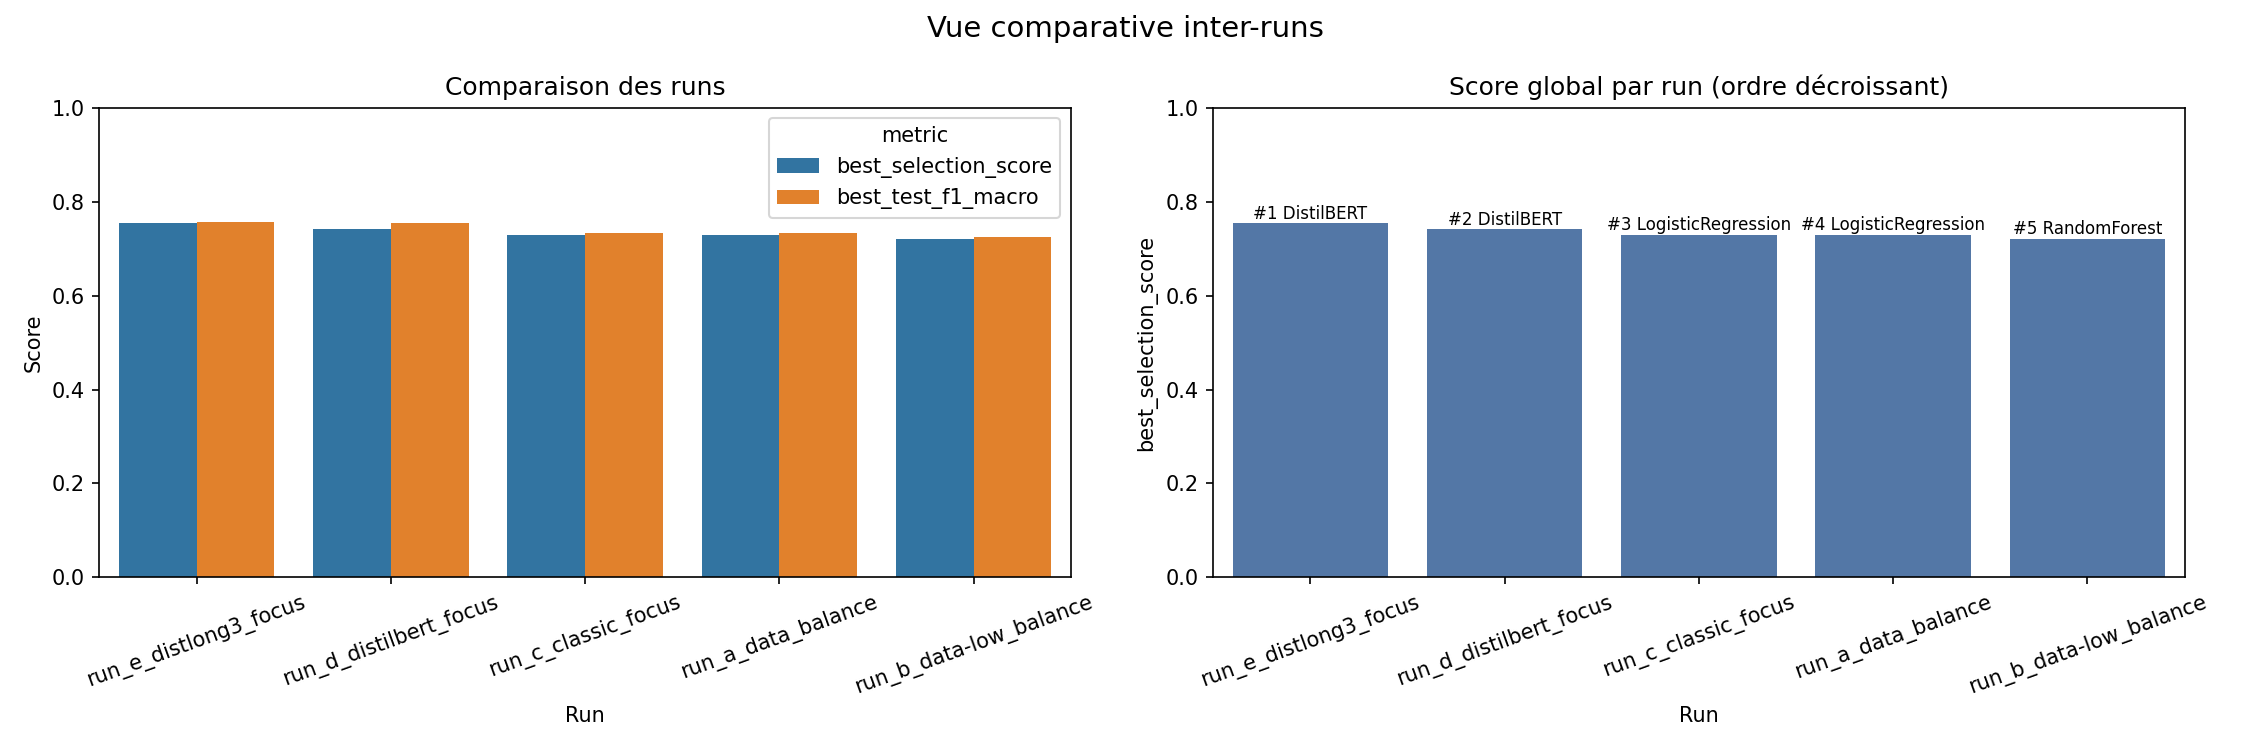

### models_compilation_overview.png

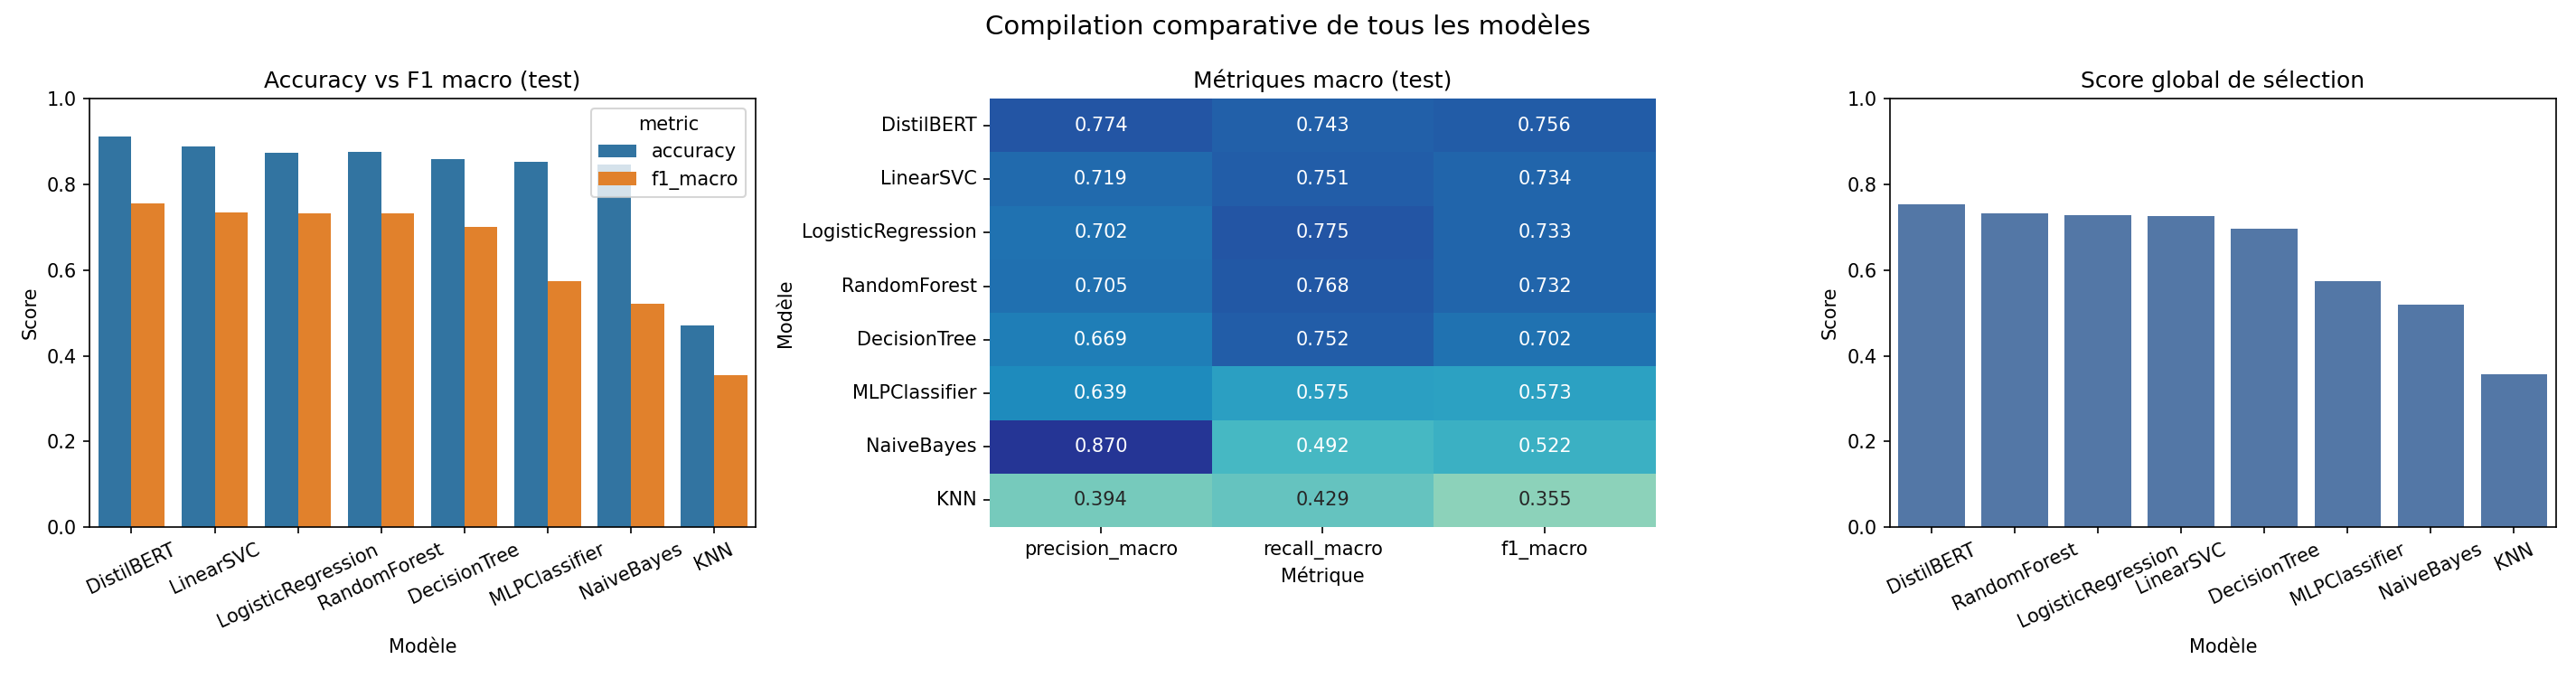

### models_status_overview.png

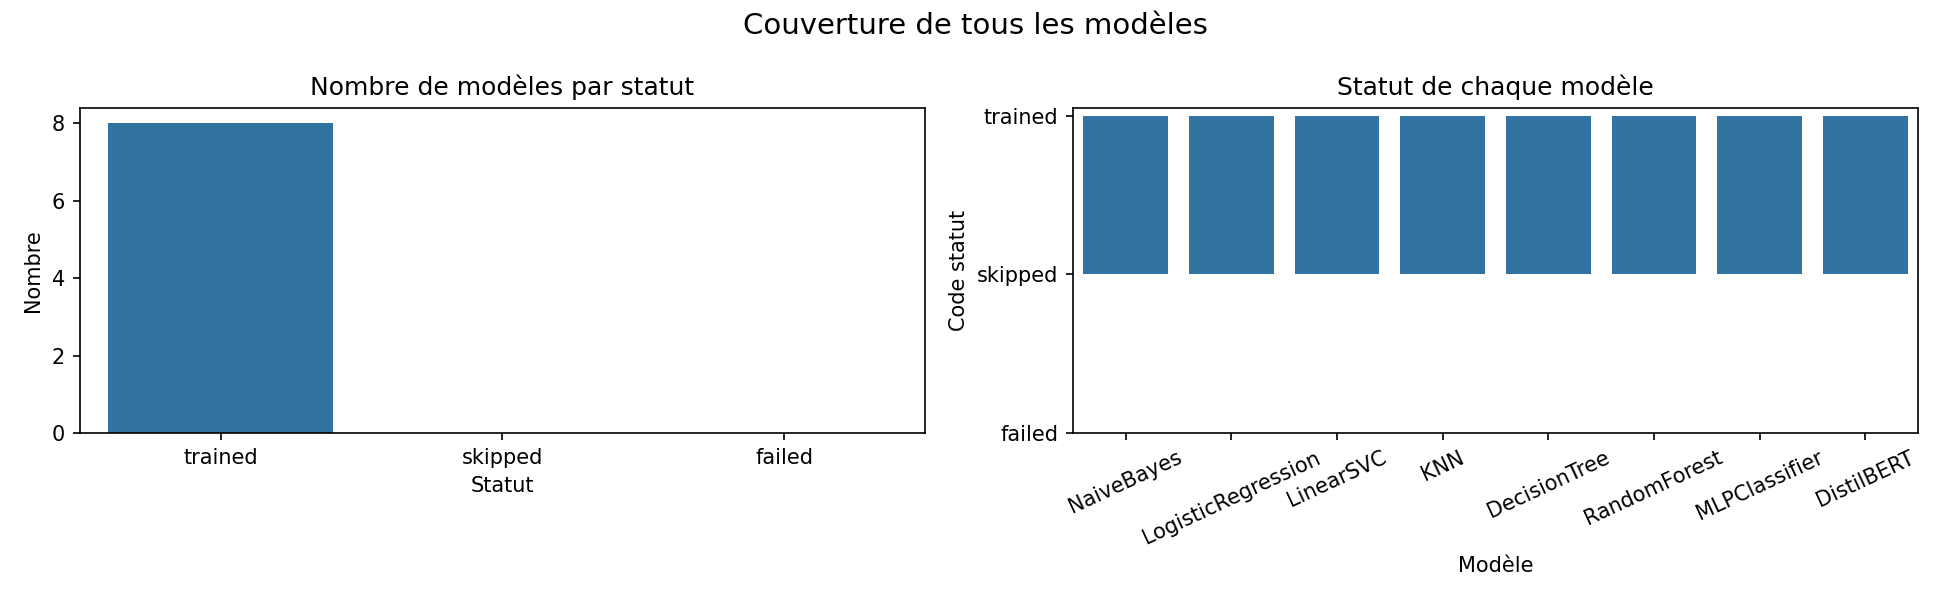

### confusion_matrices_all_models.png

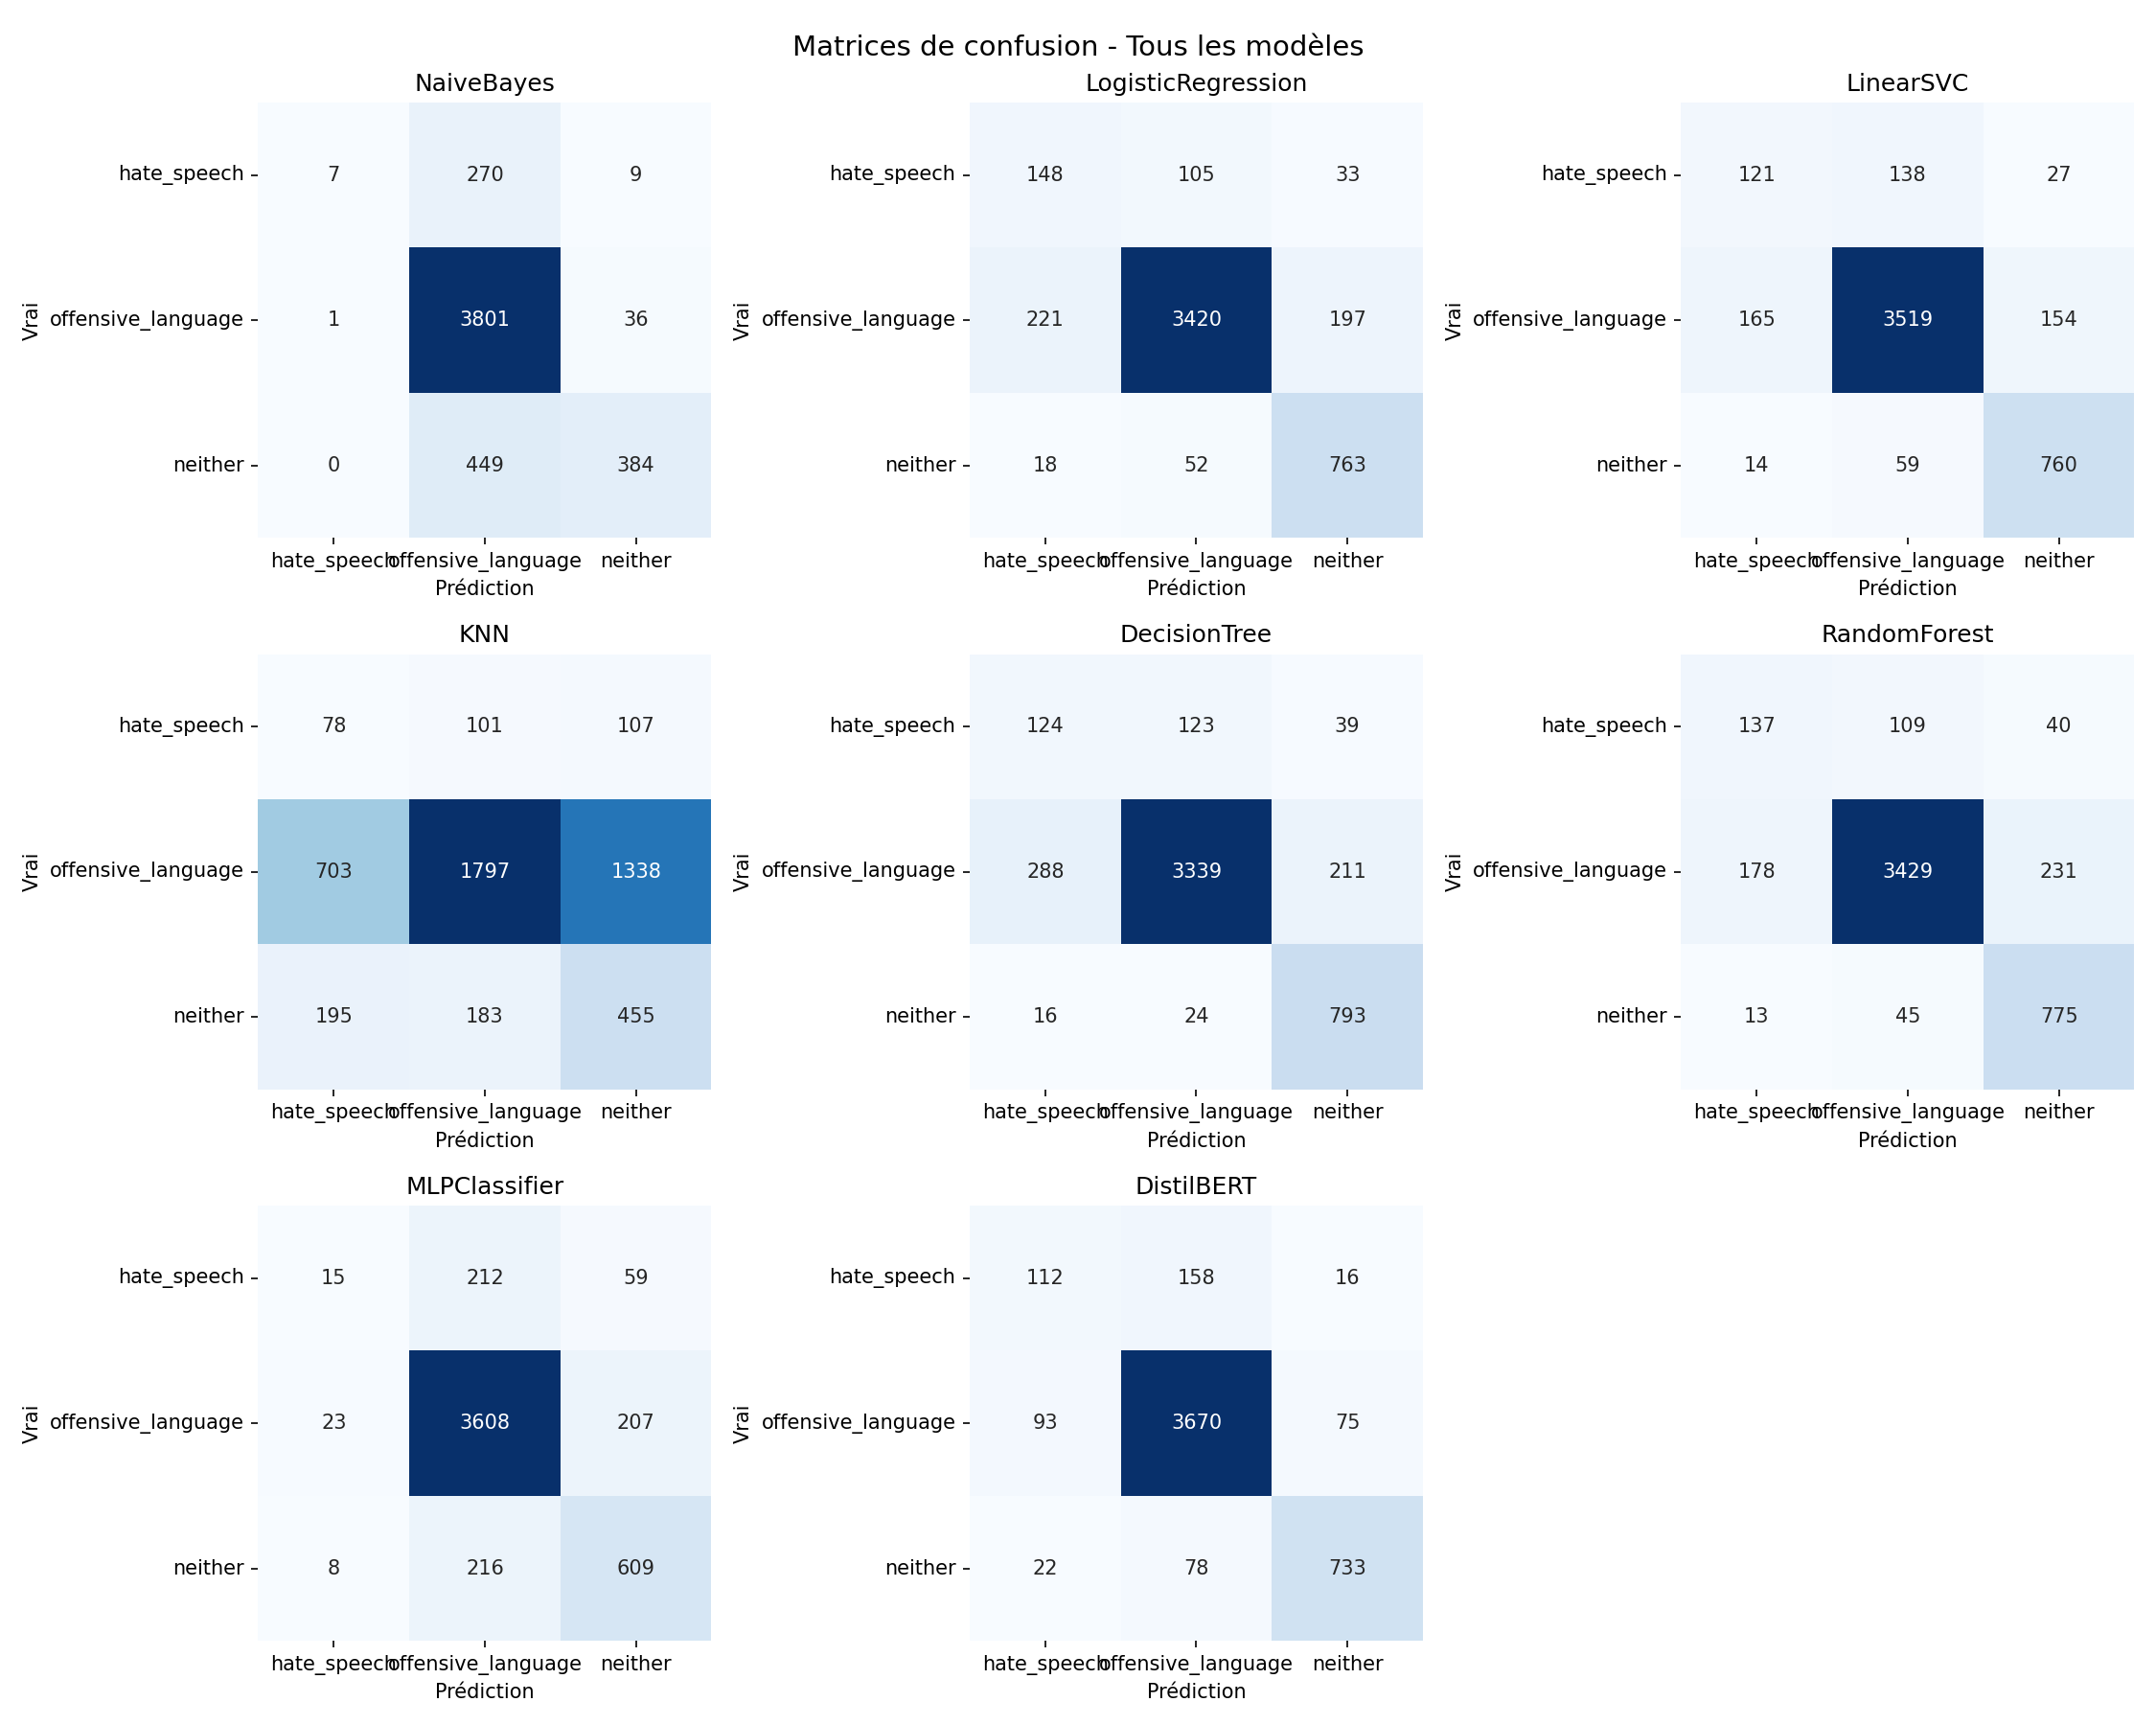

### models_comparison_test.png

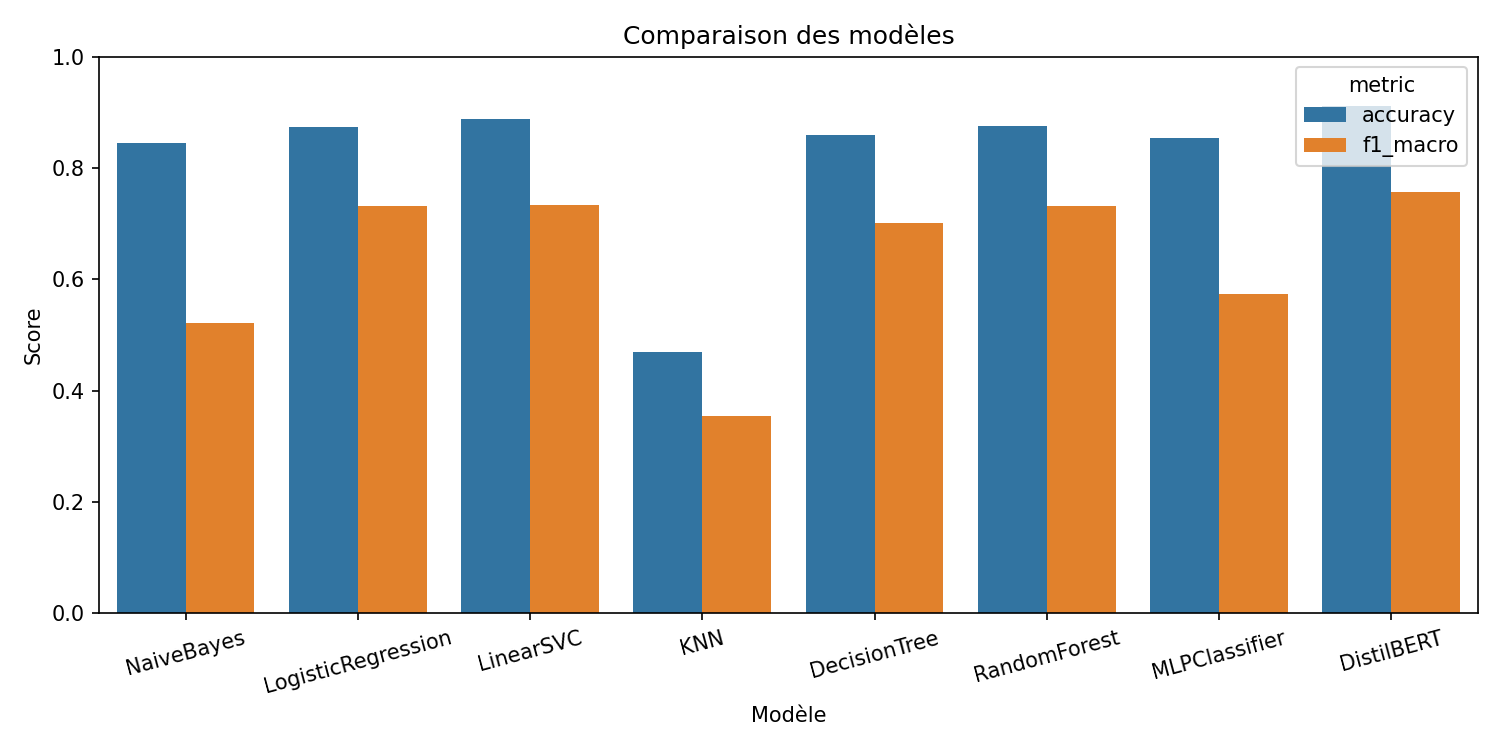

### learning_curve_best_model.png

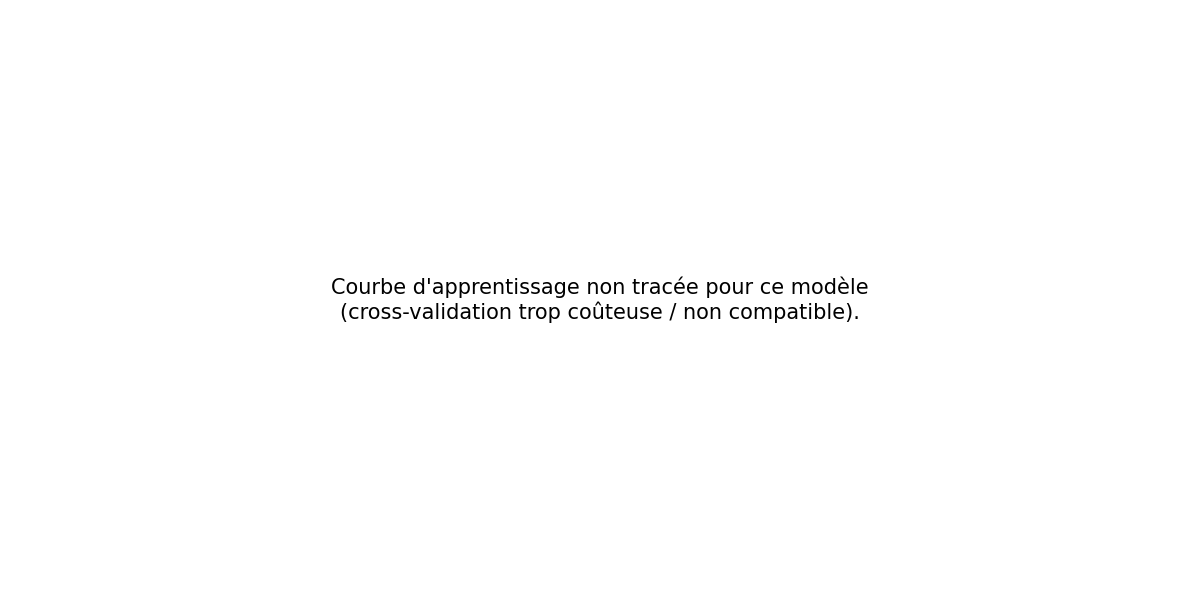

In [7]:
fig_dir = Path(artifacts["figures_dir"])
for fig_name in FIGURE_NAMES:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f"### {fig_name}"))
        display(Image(filename=str(fig_path)))
    else:
        print(f"Figure absente: {fig_path}")